# Importing libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import ast

tqdm.pandas()

# Loading the dataset

In [91]:
df = pd.read_csv('../datasets/scin/metadata.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5033 entries, 0 to 5032
Data columns (total 73 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   case_id                                             5033 non-null   int64  
 1   source                                              5033 non-null   object 
 2   release                                             5033 non-null   object 
 3   year                                                5033 non-null   int64  
 4   age_group                                           5032 non-null   object 
 5   sex_at_birth                                        5032 non-null   object 
 6   fitzpatrick_skin_type                               2503 non-null   object 
 7   race_ethnicity_american_indian_or_alaska_native     73 non-null     object 
 8   race_ethnicity_asian                                96 non-null     object 
 9

# Dataset processing

In [ ]:
def extract_label_single(df):
    """
    Usa a label única e confiança única por linha.
    """
    df = df.copy()
    df['best_label'] = df['dermatologist_skin_condition_on_label_name']
    df['best_confidence'] = df['dermatologist_skin_condition_confidence']
    return df

In [ ]:
def explode_images_by_quality(df):
    quality_cols = [
        'dermatologist_gradable_for_skin_condition_1',
        'dermatologist_gradable_for_skin_condition_2',
        'dermatologist_gradable_for_skin_condition_3'
    ]

    image_cols = ['image_1_path', 'image_2_path', 'image_3_path']

    rows = []
    for _, row in df.iterrows():
        labels_str = row['best_label']
        confs_str = row['best_confidence']
        
        try:
            labels = ast.literal_eval(labels_str)
            confs = ast.literal_eval(confs_str)
        except Exception:
            continue
        
        if not (isinstance(labels, list) and isinstance(confs, list)):
            continue
        if len(labels) != len(confs):
            continue
        if len(confs) == 0:
            continue
        
        max_conf = max(confs)
        if confs.count(max_conf) > 1:
            continue
        
        max_index = confs.index(max_conf)
        label = labels[max_index]

        for i, img_col in enumerate(image_cols):
            img_path = row[img_col]
            quality_col = quality_cols[i]
            if pd.isna(img_path) or img_path.strip() == '':
                continue
            if row[quality_col] != "DEFAULT_YES_IMAGE_QUALITY_SUFFICIENT":
                continue
            rows.append({
                'img_id': img_path.replace('/', '_'),
                'label': label,
                'confidence': max_conf
            })

    df_exp = pd.DataFrame(rows)
    return df_exp

In [93]:
df_labeled = extract_label_single(df)
df_final = explode_images_by_quality(df_labeled)

print(df_final.head())

                                    img_id                 label  confidence
0  dataset_images_-4027806997035329030.png              Impetigo           2
1   dataset_images_-815168034213335912.png             Urticaria           5
2   dataset_images_8479707042238010445.png             Urticaria           5
3   dataset_images_-220649468572111832.png  Basal Cell Carcinoma           4
4   dataset_images_-217828380359571871.png                Eczema           4


# Label padronization

In [94]:
malignant_classes = [
    "Basal Cell Carcinoma",
    "SCC/SCCIS",
    "Melanoma",
    "Cutaneous T Cell Lymphoma",
    "B-Cell Cutaneous Lymphoma",
    "Cutaneous sarcoidosis",
    "Kaposi's sarcoma of skin",
    "Cutaneous metastasis",
    "Cutaneous T Cell Lymphoma"
]

df_final['benign_malignant'] = df_final['label'].apply(
    lambda x: 'malignant' if x in malignant_classes else 'benign'
)
df_final = df_final.drop(columns=['label', 'confidence'])

df = df_final
print(df.head())

                                    img_id benign_malignant
0  dataset_images_-4027806997035329030.png           benign
1   dataset_images_-815168034213335912.png           benign
2   dataset_images_8479707042238010445.png           benign
3   dataset_images_-220649468572111832.png        malignant
4   dataset_images_-217828380359571871.png           benign


# Viewing the label distribution

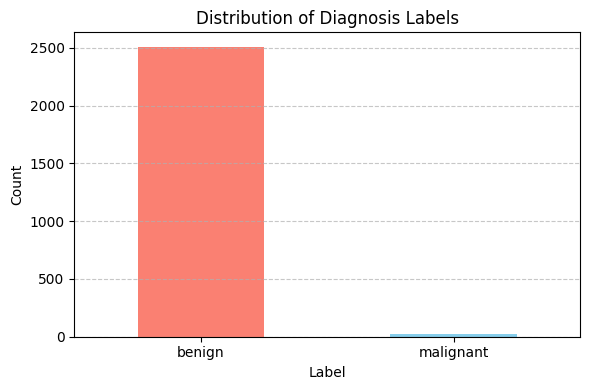


Category distribution:
benign_malignant
benign       2508
malignant      25
Name: count, dtype: int64


In [95]:
# Count label occurrences
label_counts = df['benign_malignant'].value_counts()

# Plot
plt.figure(figsize=(6, 4))
label_counts.plot(kind='bar', color=['salmon', 'skyblue'])

plt.title('Distribution of Diagnosis Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.tight_layout()
plt.show()

print("\nCategory distribution:")
print(df['benign_malignant'].value_counts())